# Analisis descriptivo de los datos climaticos

In [21]:
!python -m pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.5 MB 1.3 MB/s eta 0:00:08
    --------------------------------------- 0.1/9.5 MB 1.2 MB/s eta 0:00:08
    --------------------------------------- 0.2/9.5 MB 1.6 MB/s eta 0:00:07
   - -------------------------------------- 0.4/9.5 MB 2.0 MB/s eta 0:00:05
   - -------------------------------------- 0.5/9.5 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/9.5 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/9.5 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.6/9.5 MB 1.4 MB/s eta 0:00:07
   -- ------------------------------------- 0.6/9.5 MB 1.4 MB/s eta 0:00:07
   -- ------------------------------------- 0.6/9.5 MB 1.3 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.5 MB 1.5 MB/s eta 0:00:06
   --- -------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!python -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!python -m pip install pandas numpy matplotlib



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carga de datos y analisis inicial

In [4]:
df = pd.read_csv('wunderground_ezeiza_2001_2026.csv')
# Ver las primeras filas
print("Las primeras filas son: \n")
print(df.head())
print("\n")

Las primeras filas son: 

   day  temp_max_f  temp_avg_f  temp_min_f  dew_max_f  dew_avg_f  dew_min_f  \
0    1          91        80.9          66         64       59.1         55   
1    2          95        84.1          72         70       66.2         64   
2    3          91        83.8          72         70       66.5         61   
3    4          95        85.0          75         73       69.9         66   
4    5          97        80.3           0         73       64.4          0   

   humidity_max  humidity_avg  humidity_min  ...  wind_avg_mph  wind_min_mph  \
0            78          49.2            31  ...           6.8             0   
1            78          56.3            39  ...           6.3             0   
2            88          57.9            36  ...           5.5             1   
3            89          62.4            41  ...           4.5             0   
4            83          53.6             0  ...           5.2             0   

   pressure_max_in

In [5]:
# Ver estadísticas descriptivas
print("Los estadisticos principales son:")
print(df.describe())

Los estadisticos principales son:
               day   temp_max_f   temp_avg_f   temp_min_f    dew_max_f  \
count  9179.000000  9179.000000  9179.000000  9179.000000  9179.000000   
mean     15.719142    72.587210    62.620928    49.498202    57.708792   
std       8.796258    11.841534    11.030567    17.300633     9.824149   
min       1.000000    39.000000    25.900000   -17.000000    25.000000   
25%       8.000000    63.000000    54.200000    43.000000    50.000000   
50%      16.000000    73.000000    62.900000    52.000000    59.000000   
75%      23.000000    82.000000    71.200000    61.000000    64.000000   
max      31.000000   196.000000    94.100000    86.000000    90.000000   

         dew_avg_f    dew_min_f  humidity_max  humidity_avg  humidity_min  \
count  9179.000000  9179.000000   9179.000000   9179.000000   9179.000000   
mean     52.095501    42.082471     92.779061     72.178745     44.698333   
std      10.545009    17.880534      8.676581     12.816076     20.0

In [6]:
# Valores nulos
print("Los valores nulos son: \n")
print(df.isnull().sum())

Los valores nulos son: 

day                0
temp_max_f         0
temp_avg_f         0
temp_min_f         0
dew_max_f          0
dew_avg_f          0
dew_min_f          0
humidity_max       0
humidity_avg       0
humidity_min       0
wind_max_mph       0
wind_avg_mph       0
wind_min_mph       0
pressure_max_in    0
pressure_avg_in    0
pressure_min_in    0
precip_total_in    0
date               0
year               0
month              0
source_url         0
dtype: int64


In [7]:
df = df.drop(columns=["precip_total_in"])

Aca se puede evidenciar que no hay valores nulos pero si hay valores atipicos en la temperatura, queda ver que otros valores atipicos pueden haber.

<Axes: >

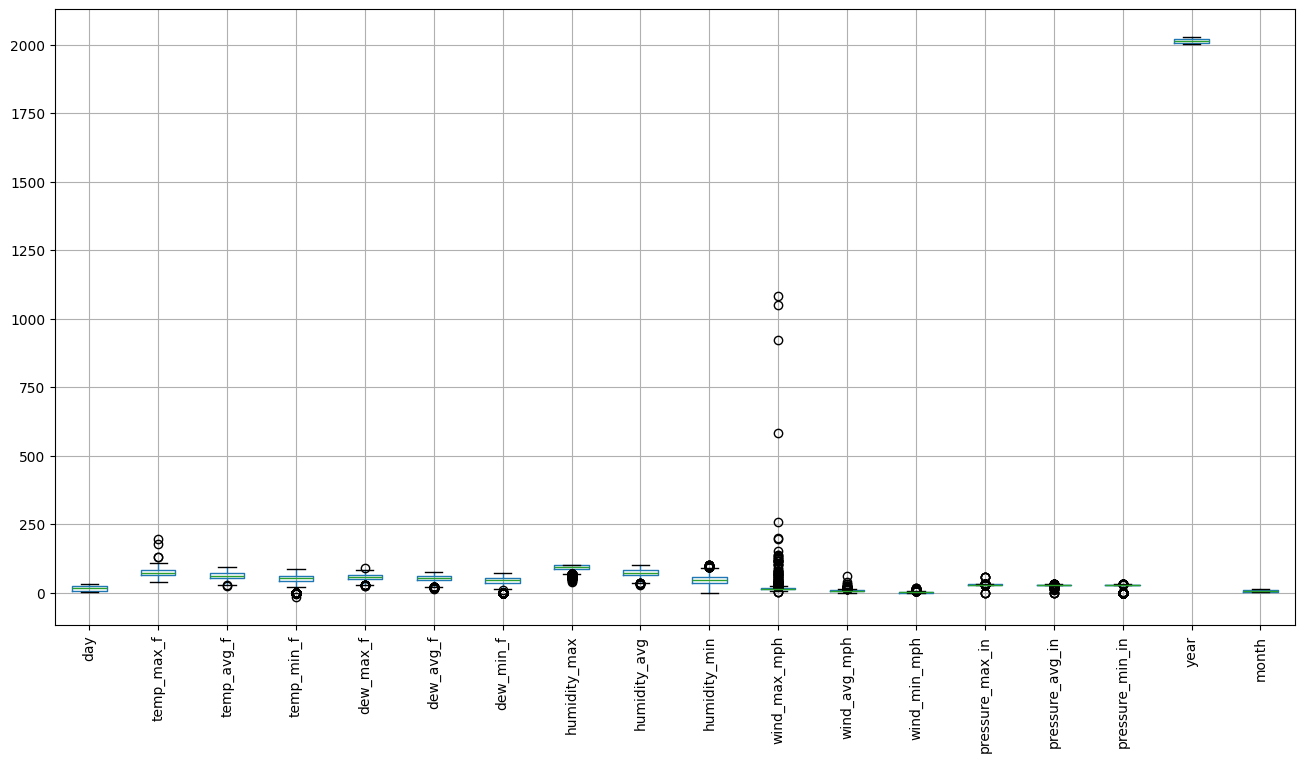

In [8]:
# Boxplot para cada columna numerica
df.select_dtypes(include="number").boxplot(figsize=(16,8), rot=90)

Se pueden observar multipls valores atipicos, observemos cada una de ellas

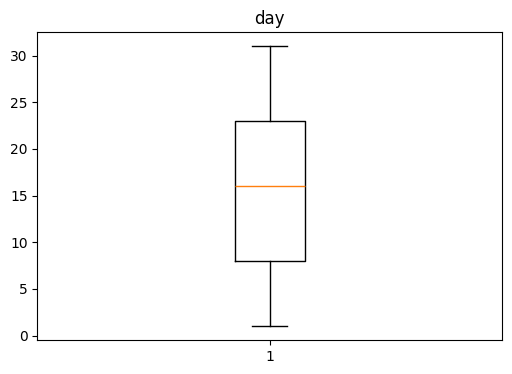

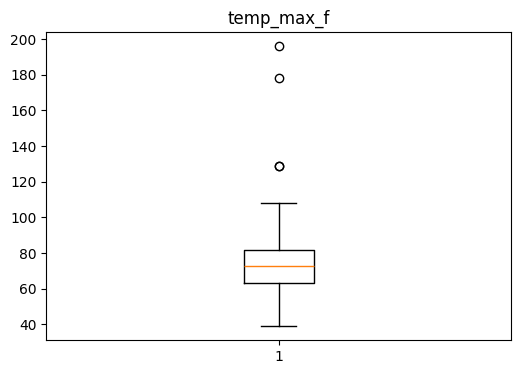

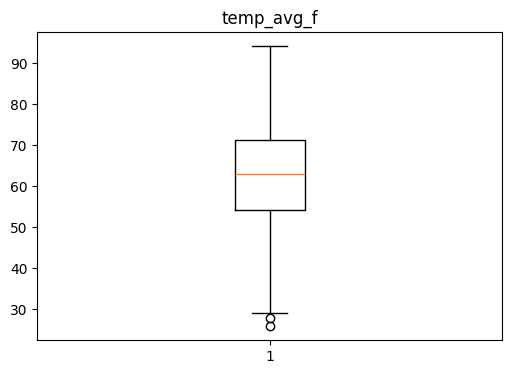

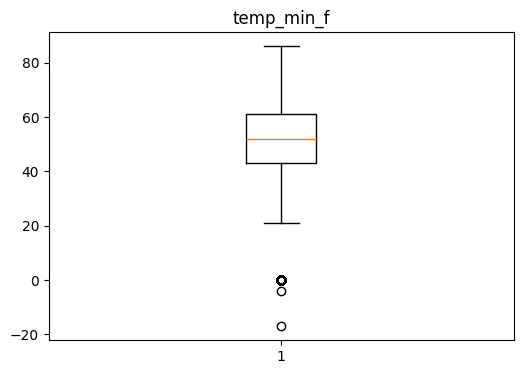

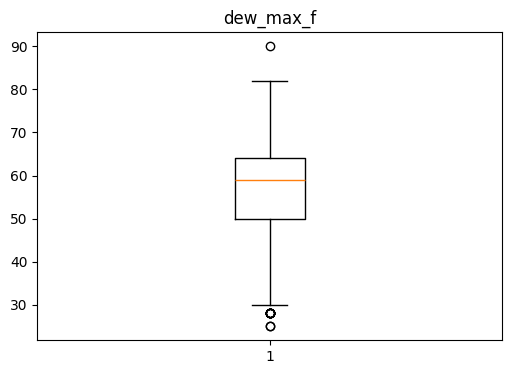

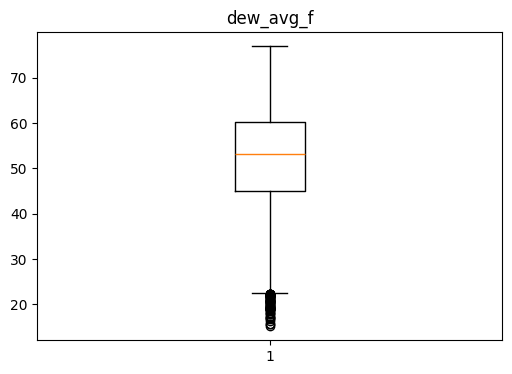

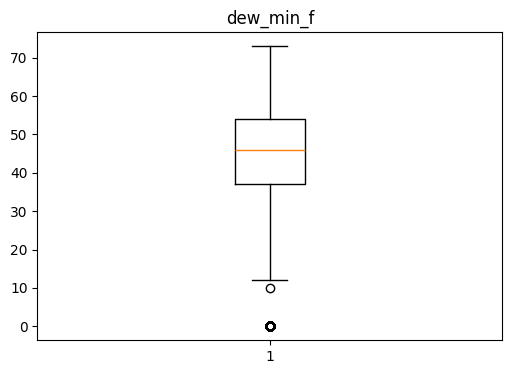

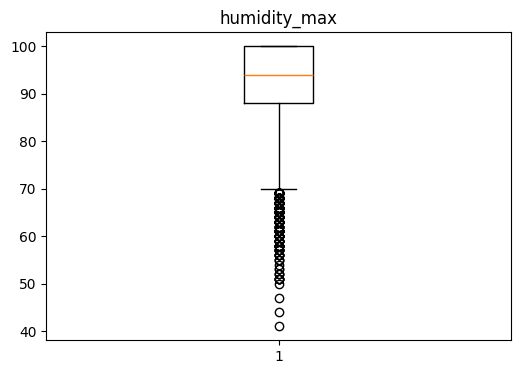

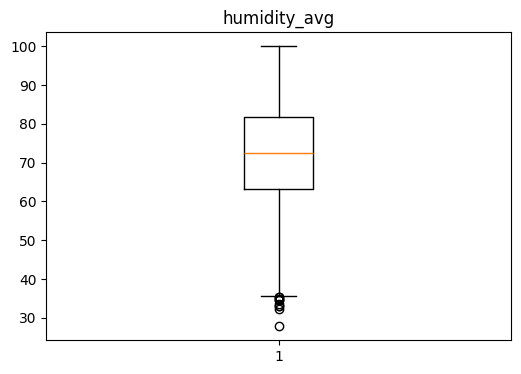

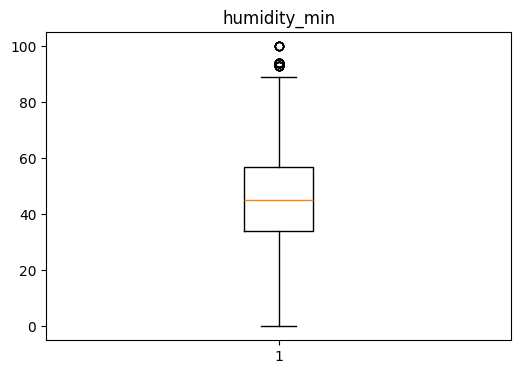

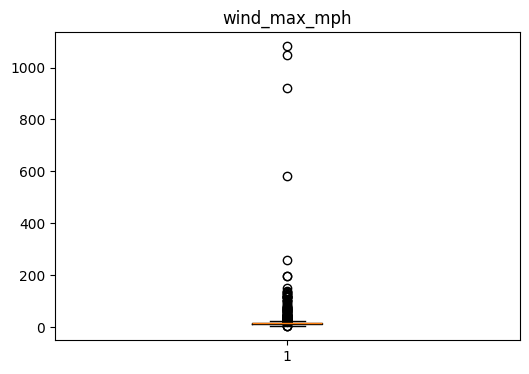

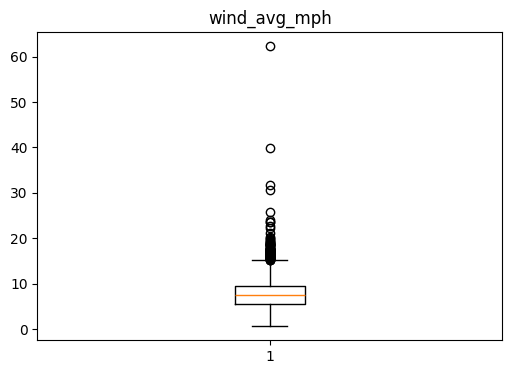

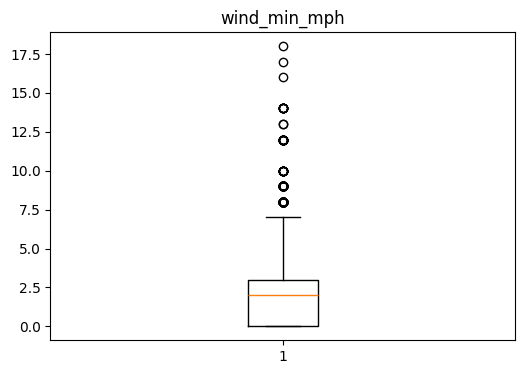

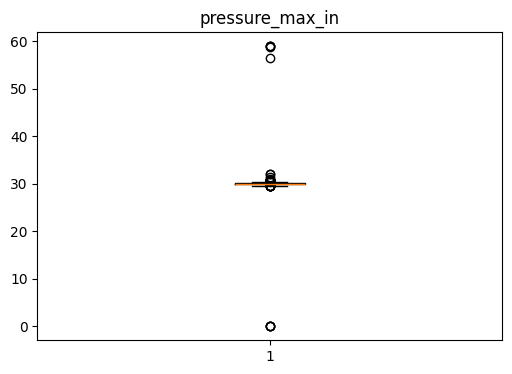

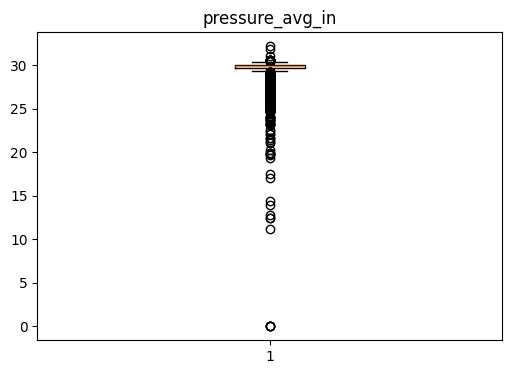

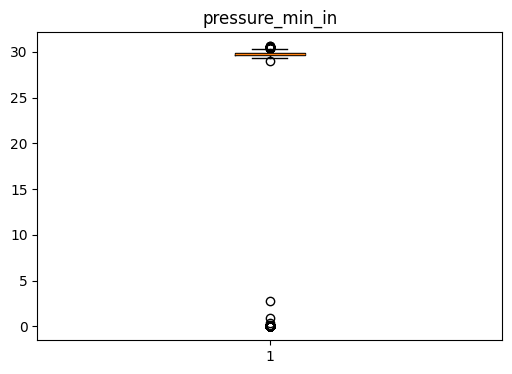

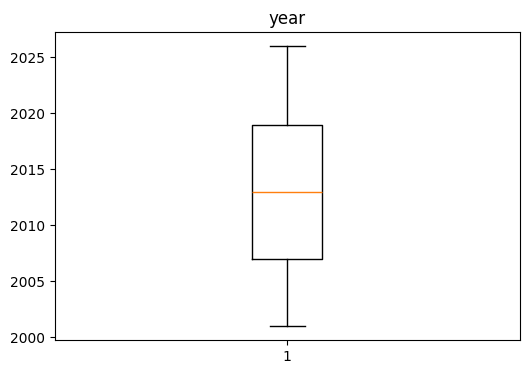

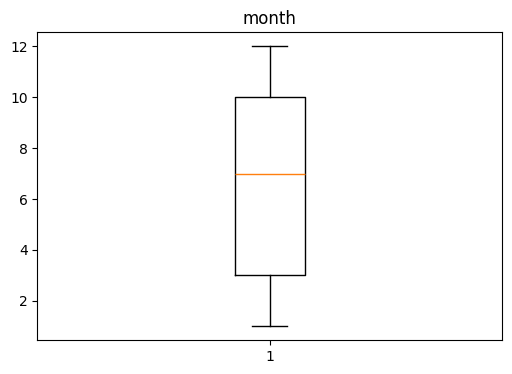

In [9]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [10]:
numeric_cols = [
    "temp_max_f", "temp_avg_f", "temp_min_f",
    "dew_max_f", "dew_avg_f", "dew_min_f",
    "wind_max_mph", "wind_avg_mph", "wind_min_mph",
    "pressure_max_in", "pressure_avg_in", "pressure_min_in"
]

df[numeric_cols] = df[numeric_cols].astype(float)
df = df.sort_values("date").reset_index(drop=True)

# Para temp_max_f
mask = df["temp_max_f"] > 110
df["temp_max_f"] = df["temp_max_f"].mask(mask).interpolate(limit_direction="both")

# Para temp_min_f
mask = df["temp_min_f"] < 20
df["temp_min_f"] = df["temp_min_f"].mask(mask).interpolate(limit_direction="both")

# Para dew_max_f
mask = df["dew_max_f"] > 83
df["dew_max_f"] = df["dew_max_f"].mask(mask).interpolate(limit_direction="both")

# Para dew_min_f
mask = df["dew_min_f"] < 10
df["dew_min_f"] = df["dew_min_f"].mask(mask).interpolate(limit_direction="both")

# Para wind_max_mph
mask = df["wind_max_mph"] > 75
df["wind_max_mph"] = df["wind_max_mph"].mask(mask).interpolate(limit_direction="both")

# Para wind_avg_mph
mask = df["wind_avg_mph"] > 30
df["wind_avg_mph"] = df["wind_avg_mph"].mask(mask).interpolate(limit_direction="both")

# Para pressure_max_in
mask = (df["pressure_max_in"] < 29.2) | (df["pressure_max_in"] > 30.8)
df["pressure_max_in"] = df["pressure_max_in"].mask(mask).interpolate(limit_direction="both")

# Para pressure_avg_in
mask = (df["pressure_avg_in"] < 29.2) | (df["pressure_avg_in"] > 30.8)
df["pressure_avg_in"] = df["pressure_avg_in"].mask(mask).interpolate(limit_direction="both")

# Para pressure_min_in
mask = (df["pressure_min_in"] < 29.0) | (df["pressure_min_in"] > 30.8)
df["pressure_min_in"] = df["pressure_min_in"].mask(mask).interpolate(limit_direction="both")

# Para mantener min <= avg <= max en cada variable
for min_col, avg_col, max_col in [
    ("temp_min_f", "temp_avg_f", "temp_max_f"),
    ("dew_min_f", "dew_avg_f", "dew_max_f"),
    ("wind_min_mph", "wind_avg_mph", "wind_max_mph"),
    ("pressure_min_in", "pressure_avg_in", "pressure_max_in")
]:
    ordered = np.sort(df[[min_col, avg_col, max_col]].to_numpy(), axis=1)
    df[min_col] = ordered[:, 0]
    df[avg_col] = ordered[:, 1]
    df[max_col] = ordered[:, 2]



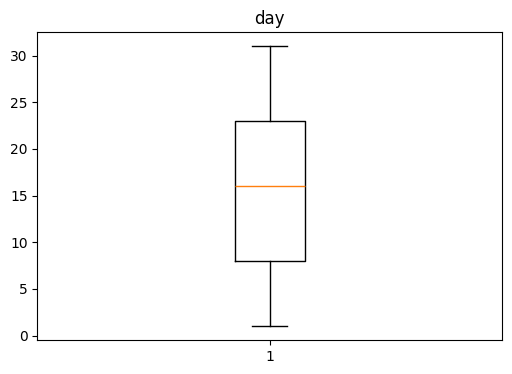

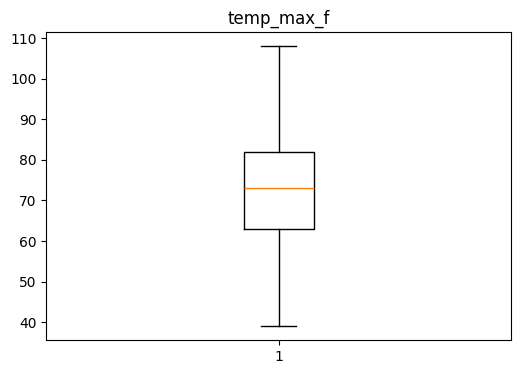

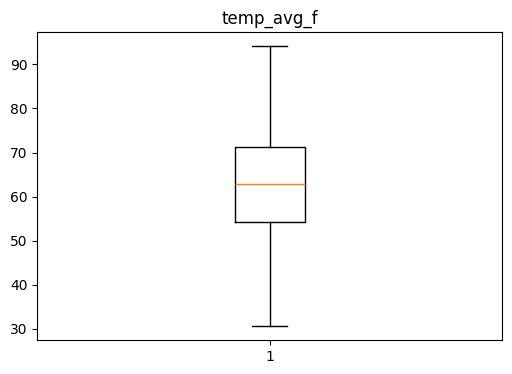

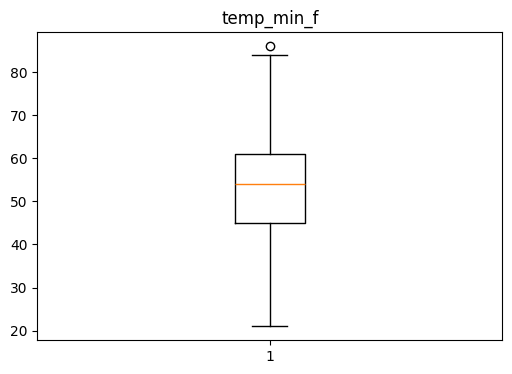

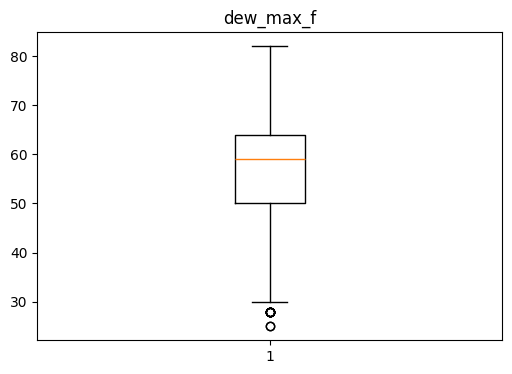

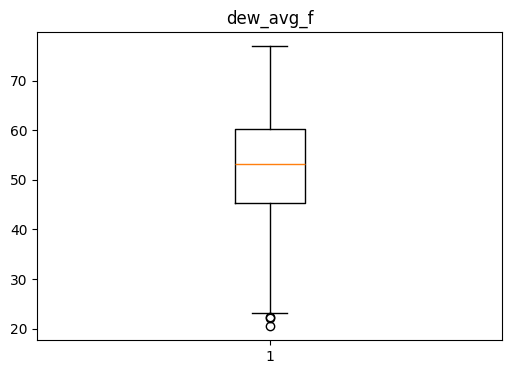

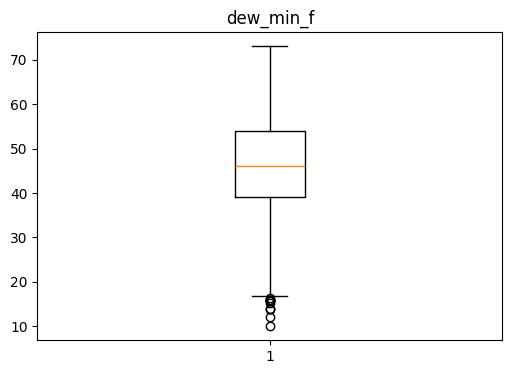

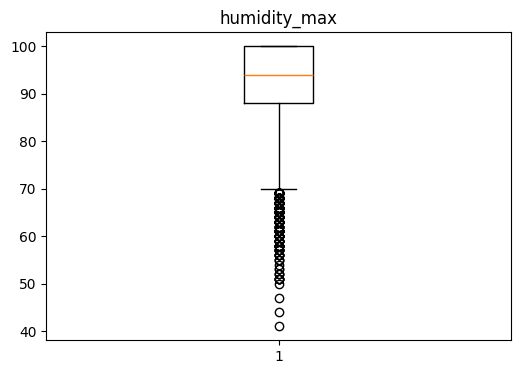

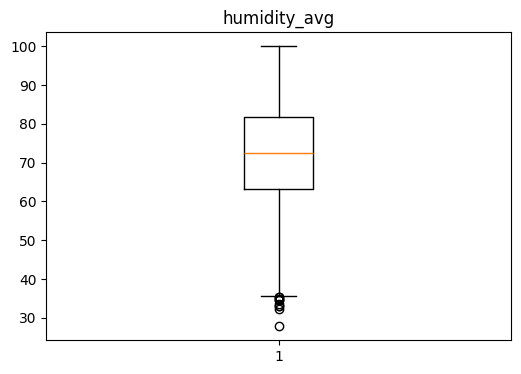

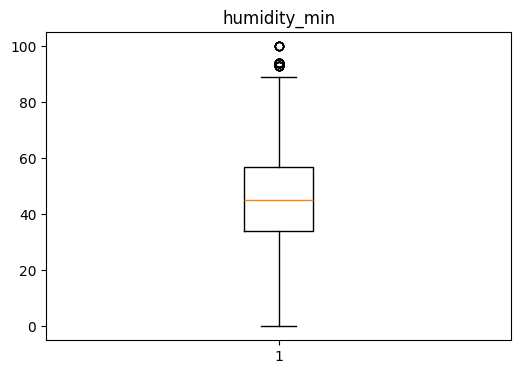

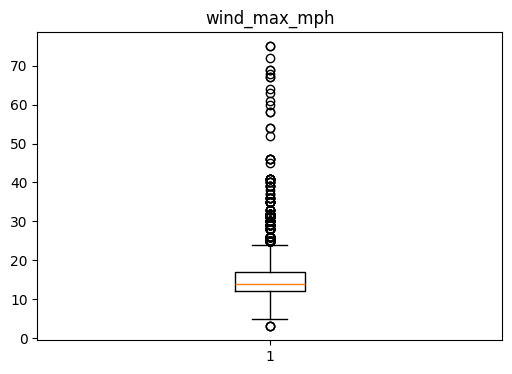

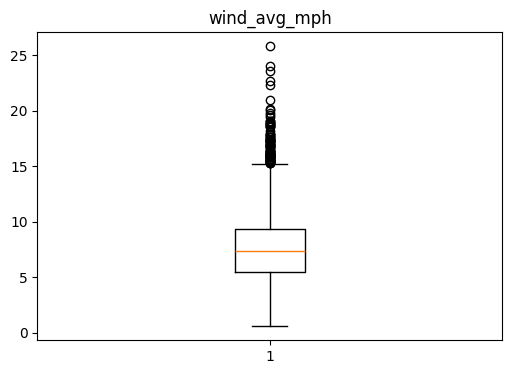

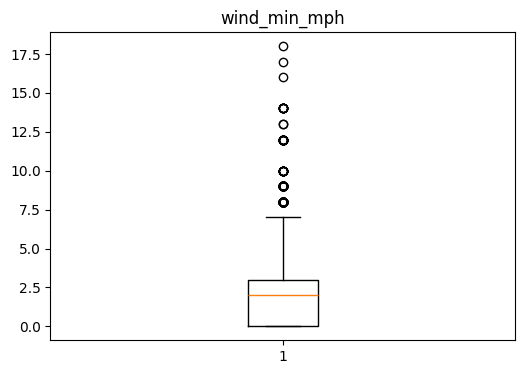

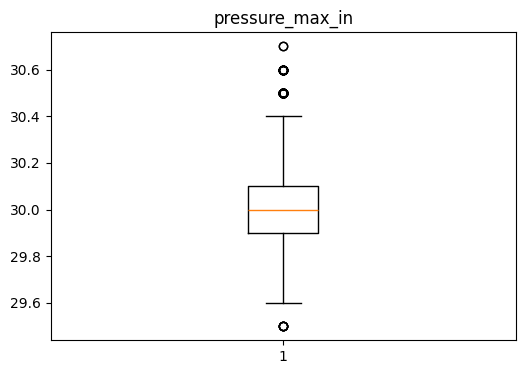

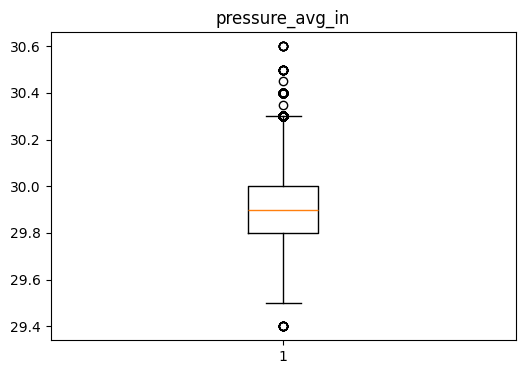

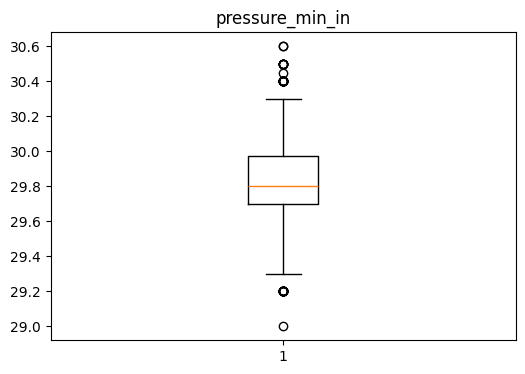

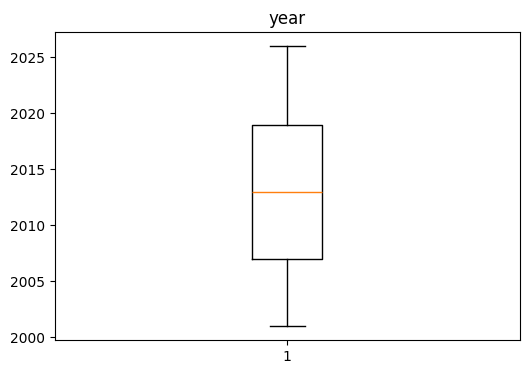

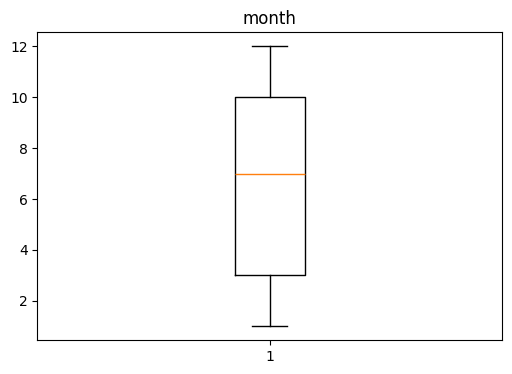

In [11]:
# Boxplot para cada columna numerica
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

Como se puede apreciar, la mayoria de valores atipicos desaparecieron. 

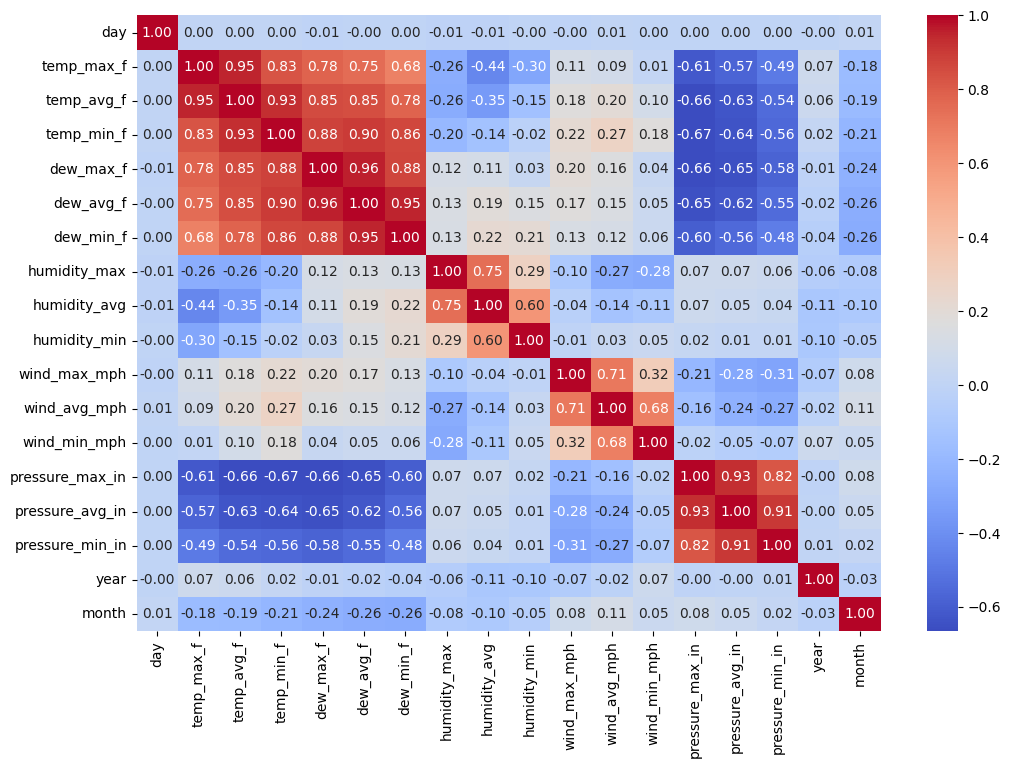

In [12]:
# Matriz de correlaccion con seaborn
corr_df = df.select_dtypes(include="number").corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_df, annot=True, cmap = "coolwarm", fmt = ".2f")
plt.show()

Las relaciones más importantes observadas son las siguientes:

1. Temperatura y punto de rocío presentan una correlación positiva fuerte, lo cual tiene sentido para Ezeiza. En general, cuando aumenta la temperatura, también aumenta el contenido de humedad en el aire. Esto se ve especialmente en las correlaciones entre temp_avg_f, temp_min_f y las variables dew_*, con valores altos y consistentes.

2. Temperatura y humedad relativa muestran una relación negativa, sobre todo con humidity_avg y humidity_min. Esto también es esperable: a medida que sube la temperatura, la humedad relativa suele bajar, aun cuando el aire contenga bastante vapor de agua.

3. Presión y temperatura / punto de rocío presentan correlaciones negativas claras. En términos meteorológicos, esto sugiere que los días más cálidos y húmedos suelen estar asociados a situaciones de presión más baja, mientras que las presiones más altas acompañan condiciones más estables, frescas y secas.

4. Las variables de viento (wind_min_mph, wind_avg_mph, wind_max_mph) están positivamente correlacionadas entre sí, lo cual es consistente: si un día fue ventoso en promedio, también es esperable que aumenten sus máximos y mínimos.

5. La relación entre viento y presión es negativa moderada, algo razonable desde el punto de vista físico, ya que los días más dinámicos suelen darse en contextos de sistemas de baja presión o mayor gradiente bárico.


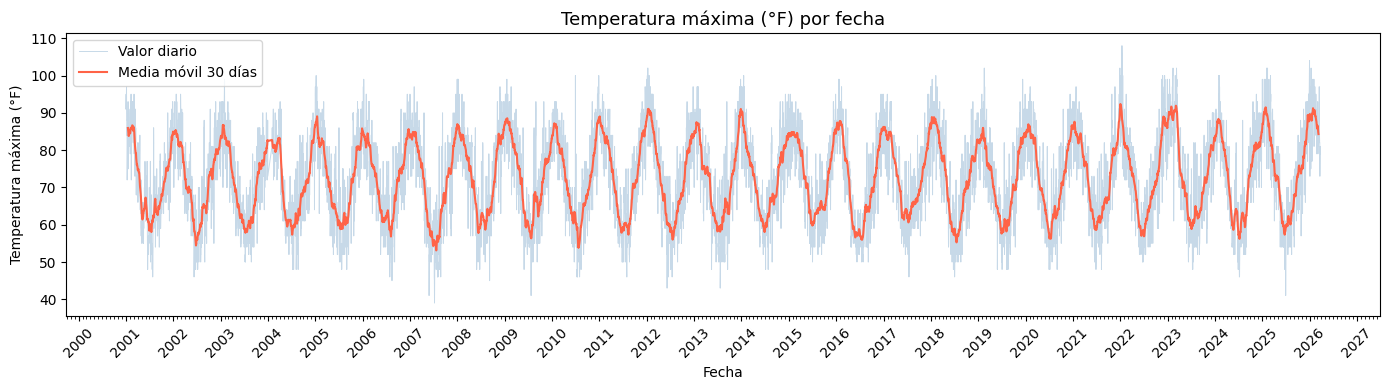

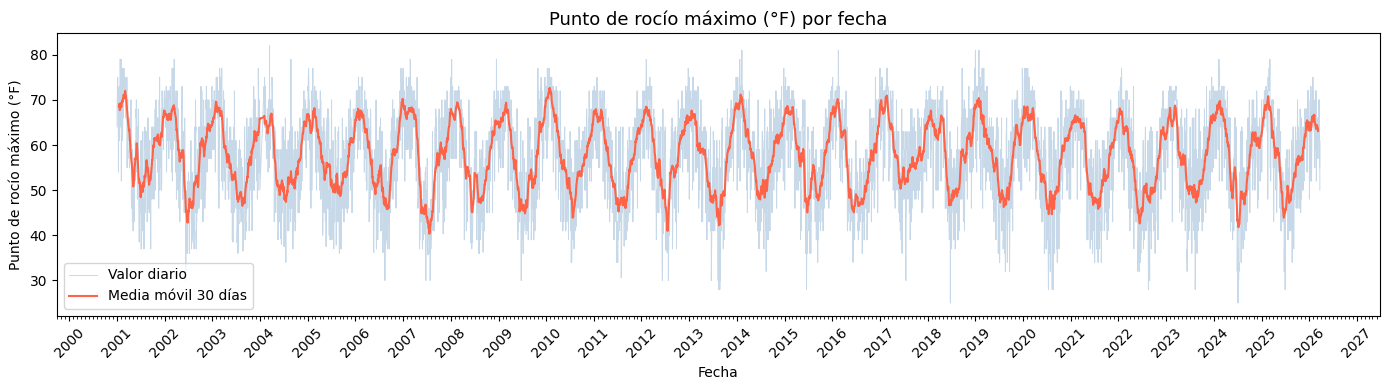

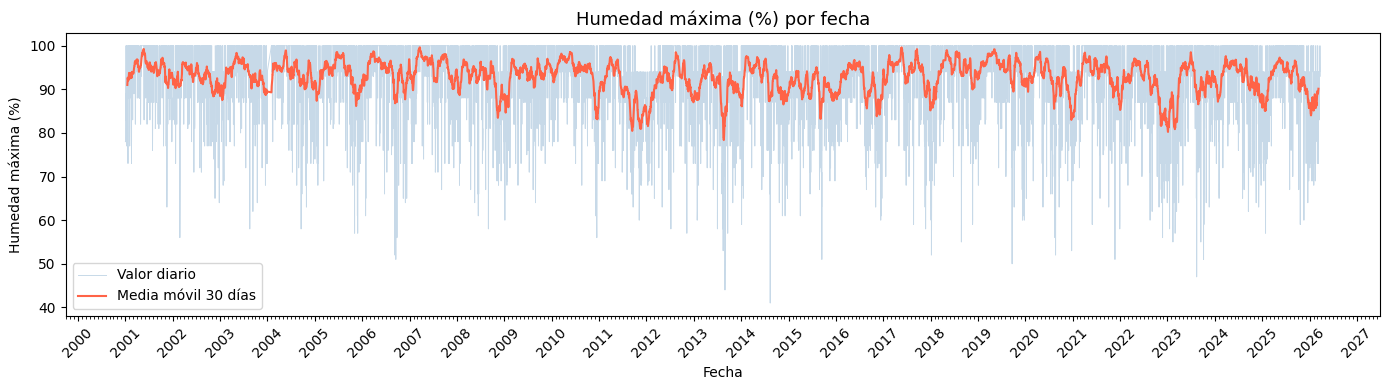

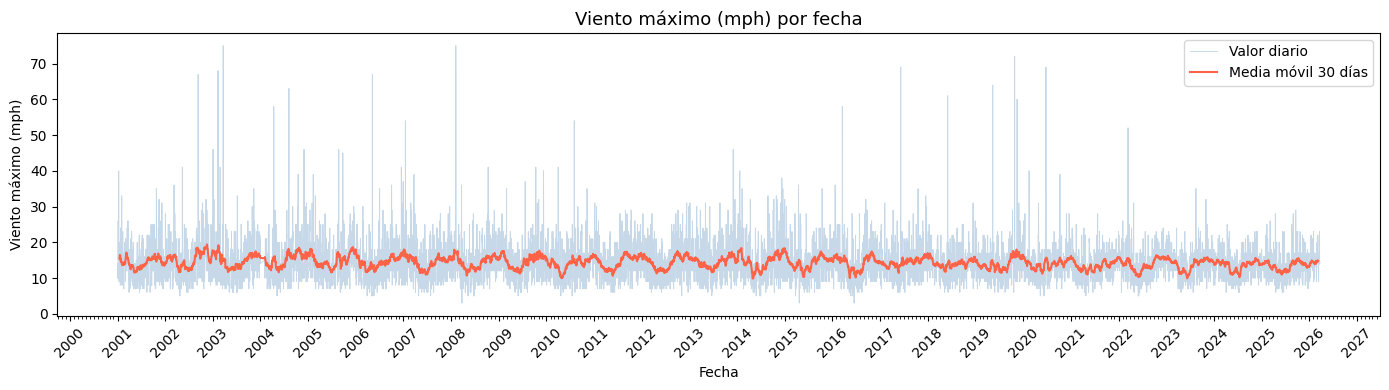

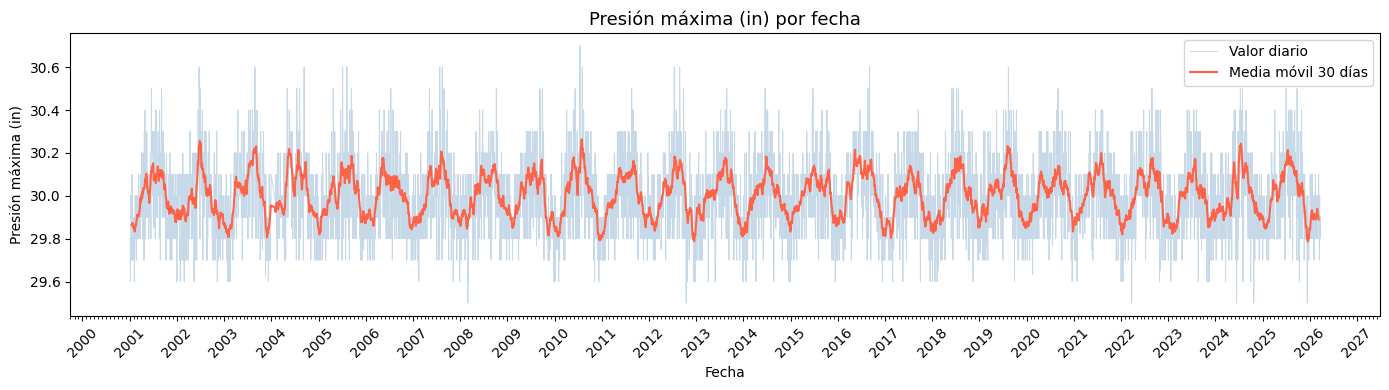

In [14]:
import matplotlib.dates as mdates

df['date'] = pd.to_datetime(df['date'])

variables = [
    ('temp_max_f',      'Temperatura máxima (°F)'),
    ('dew_max_f',       'Punto de rocío máximo (°F)'),
    ('humidity_max',    'Humedad máxima (%)'),
    ('wind_max_mph',    'Viento máximo (mph)'),
    ('pressure_max_in', 'Presión máxima (in)'),
]

for col, label in variables:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df['date'], df[col], alpha=0.3, linewidth=0.7,
            color='steelblue', label='Valor diario')
    rolling = df[col].rolling(30, center=True).mean()
    ax.plot(df['date'], rolling, linewidth=1.5,
            color='tomato', label='Media móvil 30 días')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f'{label} por fecha', fontsize=13)
    ax.set_xlabel('Fecha')
    ax.set_ylabel(label)
    ax.legend()
    plt.tight_layout()
    plt.show()


Claramente existe un componente periodico a lo largo de los anos.

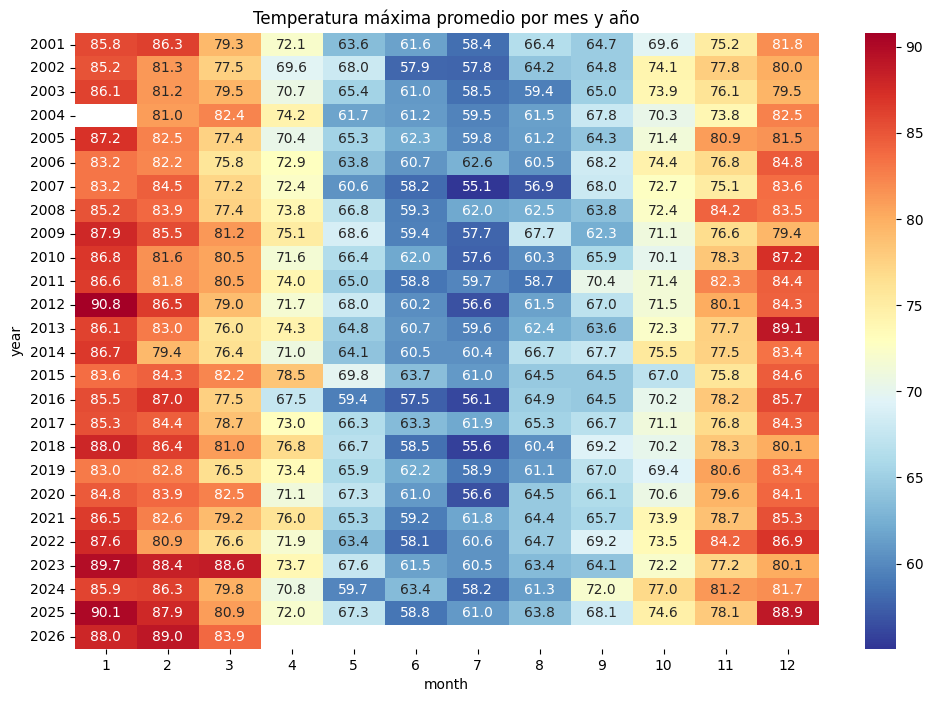

In [15]:
# Promedio mensual de temp_max_f por año (heatmap)
pivot = df.pivot_table(values='temp_max_f', index='year', columns='month', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r')
plt.title('Temperatura máxima promedio por mes y año')
plt.show()


El mapa de calor confirma visualmente la fuerte estacionalidad de la serie temporal mediante bandas verticales de color, contrastando claramente los veranos cálidos (tonos rojos y anaranjados en los meses 1-3 y 12) con los inviernos fríos (tonos azules en los meses centrales). Al observar las columnas de verano a lo largo de los años, se sugiere una posible tendencia de calentamiento, evidenciada por una mayor frecuencia de promedios mensuales cercanos o superiores a 90°F en la última década (como en 2012, 2023 y 2025).

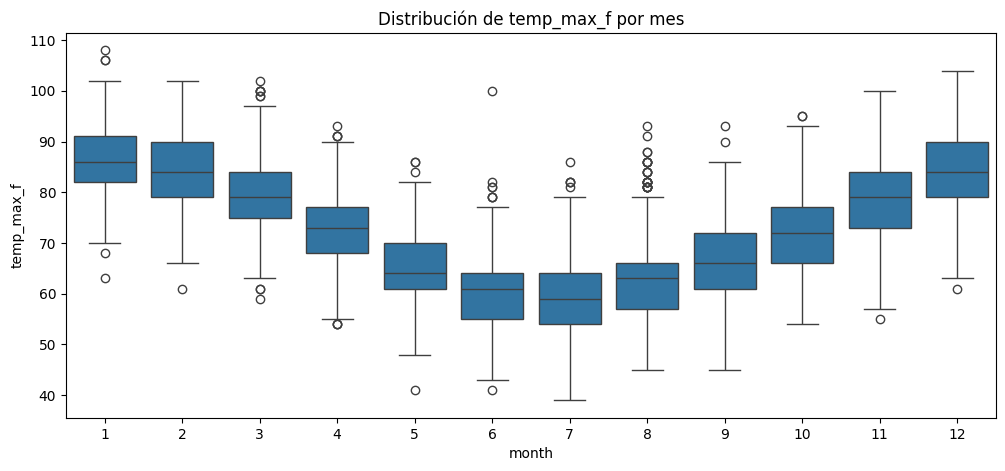

In [16]:
# Boxplot de temp_max_f por mes (ver distribución estacional)
plt.figure(figsize=(12, 5))
sns.boxplot(x='month', y='temp_max_f', data=df)
plt.title('Distribución de temp_max_f por mes')
plt.show()


De este grafico se pueden apreciar dos cosas:

1. Patrón Estacional Claro (Hemisferio Sur): El gráfico confirma una fuerte estacionalidad anual. Las medianas de temperatura máxima alcanzan su pico en verano (enero/febrero y diciembre, rondando los 85°F) y su valle en invierno (junio/julio, cerca de los 60°F).

2. Olas de Calor (Outliers Superiores): Durante los meses de verano (1, 2, 3 y 12) se observa una concentración de valores atípicos por encima de los 95°F y 100°F, lo que refleja eventos extremos de calor.

In [17]:
# Correlación de todas las variables numéricas con temp_max_f
corr_target = df.select_dtypes(include='number').corr()['temp_max_f'].sort_values(ascending=False)
print(corr_target)


temp_max_f         1.000000
temp_avg_f         0.954362
temp_min_f         0.830401
dew_max_f          0.780442
dew_avg_f          0.748866
dew_min_f          0.676921
wind_max_mph       0.113944
wind_avg_mph       0.089137
year               0.071657
wind_min_mph       0.010619
day                0.004557
month             -0.178294
humidity_max      -0.257828
humidity_min      -0.297134
humidity_avg      -0.438043
pressure_min_in   -0.486743
pressure_avg_in   -0.570512
pressure_max_in   -0.614802
Name: temp_max_f, dtype: float64


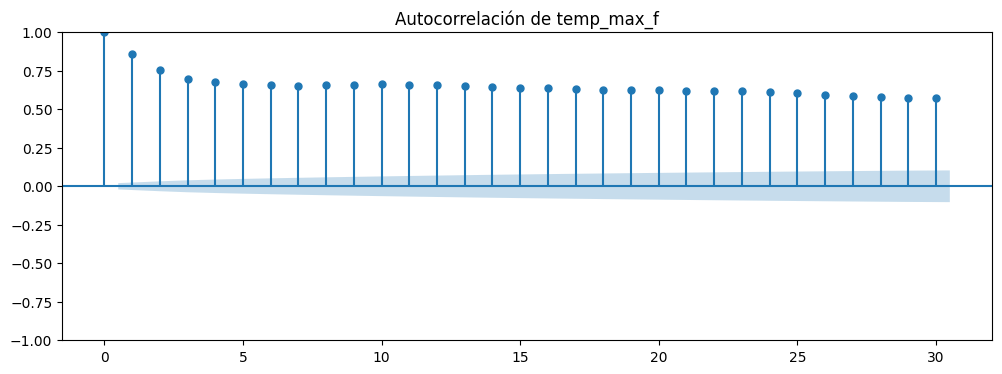

In [22]:
# Autocorrelación de temp_max_f hasta 30 días
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['temp_max_f'].dropna(), lags=30, ax=ax)
plt.title('Autocorrelación de temp_max_f')
plt.show()


Se puede apreciar una Fuerte "memoria" a corto y mediano plazo. Esto significa que la temperatura de hoy está fuertemente correlacionada no solo con la de ayer (rezago 1), sino también con la de hace una semana o incluso hace 30 días

In [23]:
# Crear lags y ver correlación con temp_max_f
for lag in [1, 2, 3, 7]:
    df[f'temp_max_lag{lag}'] = df['temp_max_f'].shift(lag)

lag_cols = [c for c in df.columns if 'lag' in c]
print(df[['temp_max_f'] + lag_cols].corr()['temp_max_f'])


temp_max_f       1.000000
temp_max_lag1    0.857246
temp_max_lag2    0.753223
temp_max_lag3    0.698830
temp_max_lag7    0.653432
Name: temp_max_f, dtype: float64


El cálculo de correlación lineal entre la temperatura máxima y sus rezagos recientes confirma numéricamente una fuerte inercia térmica en la serie. El rezago de un día (lag1) presenta una altísima correlación positiva de 0.85, indicando que la temperatura de ayer es el mejor predictor individual para la temperatura de hoy. A medida que retrocedemos en el tiempo (lag2 y lag3), la correlación decae gradualmente (0.75 y 0.69 respectivamente), pero sigue siendo estadísticamente muy fuerte. Resulta notable que incluso con un rezago de siete días (lag7), la correlación se mantiene alta en un 0.65; esto sugiere que los sistemas meteorológicos o frentes de temperatura en esta región tienden a persistir o tener ciclos de influencia que duran al menos una semana

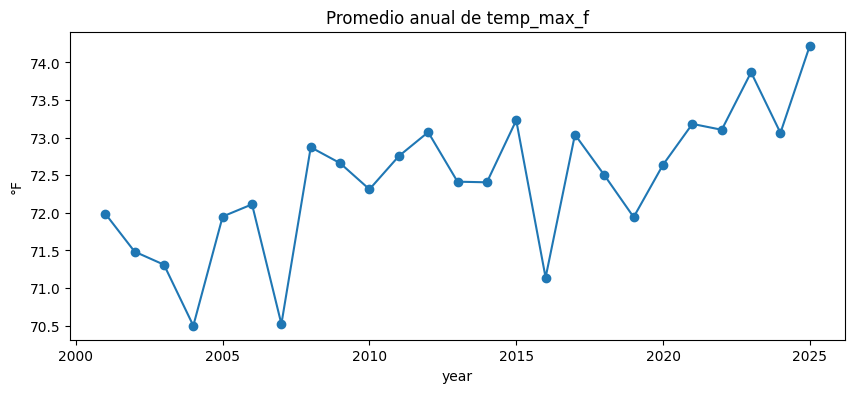

In [25]:
yearly_avg = df[df['year'] <= 2025].groupby('year')['temp_max_f'].mean()
plt.figure(figsize=(10, 4))
yearly_avg.plot(marker='o')
plt.title('Promedio anual de temp_max_f')
plt.ylabel('°F')
plt.show()



Este gráfico de líneas revela una clara tendencia alcista a largo plazo en las temperaturas máximas promedio durante los últimos 25 años, confirmando las sospechas de calentamiento que insinuaba el mapa de calor